# Analisis User Study — Fashion Recommender A/B Evaluation

**Sumber data:** `data/fashion_user_study.csv` (50 responden)  
**Item metadata:** `dataset/master_dataset.csv` (7975 items)  
**Tujuan:** Menarik kesimpulan dan insight dari data user study yang dilakukan melalui form Streamlit.

In [1]:
# Disable output scrolling for all cells
from IPython.display import HTML
HTML('''<style>
div.output_area pre { max-height: none !important; overflow: visible !important; }
div.output_scroll { height: auto !important; overflow: visible !important; }
</style>''')

---
## Cell 1 — Setup & Data Loading

In [2]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)

# ── Resolve paths ──
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
CSV_PATH   = os.path.join(ROOT, 'data', 'fashion_user_study.csv')
MASTER_CSV = os.path.join(ROOT, 'dataset', 'master_dataset.csv')

# ── Load user study ──
df = pd.read_csv(CSV_PATH)

# Clean session_id (Excel may mangle long hex strings)
df['session_id'] = df['session_id'].astype(str).str.replace(',', '').str.strip()

# ── Parse semicolon-separated columns ──
list_cols = [
    'cold_start_items', 'liked_cold_start',
    'recs_a_items', 'recs_b_items',
    'liked_a_items', 'liked_b_items'
]
for col in list_cols:
    df[col + '_list'] = df[col].fillna('').apply(
        lambda x: [int(v.strip()) for v in str(x).split(';') if v.strip().isdigit()]
    )

# ── Derive engine columns ──
df['engine_a_is_cnn'] = df['col_a_engine'].str.lower() == 'cnn'

# Map preference to actual engine name
def map_pref(row):
    if pd.isna(row['preference']) or row['preference'] == 'equal':
        return 'Equal'
    if row['preference'] == 'A':
        return 'CNN' if row['engine_a_is_cnn'] else 'Text'
    if row['preference'] == 'B':
        return 'Text' if row['engine_a_is_cnn'] else 'CNN'
    return 'Equal'

df['preferred_engine'] = df.apply(map_pref, axis=1)

# ── Compute CNN/Text liked counts ──
# Merge 'Kadang-kadang' and 'Jarang' into single category (3-level scale)
_diff_map = {
    'Kadang-kadang — terkadang sulit': 'Kadang-kadang',
    'Jarang — biasanya mudah menemukan': 'Kadang-kadang',
    'Sering — hampir selalu sulit menemukan yang cocok': 'Sering',
    'Tidak pernah — selalu mudah': 'Tidak pernah',
}
df['difficulty_experience'] = df['difficulty_experience'].map(_diff_map).fillna(df['difficulty_experience'])

df['n_liked_cnn']  = df.apply(lambda r: len(r['liked_a_items_list']) if r['engine_a_is_cnn'] else len(r['liked_b_items_list']), axis=1)
df['n_liked_text'] = df.apply(lambda r: len(r['liked_b_items_list']) if r['engine_a_is_cnn'] else len(r['liked_a_items_list']), axis=1)

# ── Load master dataset for item metadata ──
master = pd.read_csv(MASTER_CSV)
item_meta = master[['db_idx', 'gender', 'category', 'clothes_type_label', 'item_id']].copy()
item_meta.rename(columns={'db_idx': 'item_idx'}, inplace=True)

print(f'User study: {df.shape[0]} responden')
print(f'Master dataset: {master.shape[0]} items')
print()
df[['session_id','age_range','gender','preferred_engine','n_liked_cold_start','n_liked_cnn','n_liked_text']].head(10)

User study: 50 responden
Master dataset: 7975 items



,session_id,age_range,gender,preferred_engine,n_liked_cold_start,n_liked_cnn,n_liked_text
0,AWAL MULAA,< 18,Pria,CNN,2,0,0
1,aa18d158,18-21,Pria,CNN,2,2,1
2,f1fb0064,< 18,Wanita,Text,2,2,2
3,4a375583,22-25,Wanita,Equal,2,6,6
4,c7d027b2,18-21,Pria,Equal,3,2,1
5,77c43f38,18-21,Pria,Text,1,0,5
6,4ce7024d,22-25,Pria,CNN,2,2,1
7,bd0820aa,18-21,Pria,Equal,4,0,1
8,4d8dc5fa,22-25,Wanita,CNN,5,4,2
9,6e6c88ba,18-21,Pria,CNN,2,2,0


---
## Cell 2 — Demographic Overview

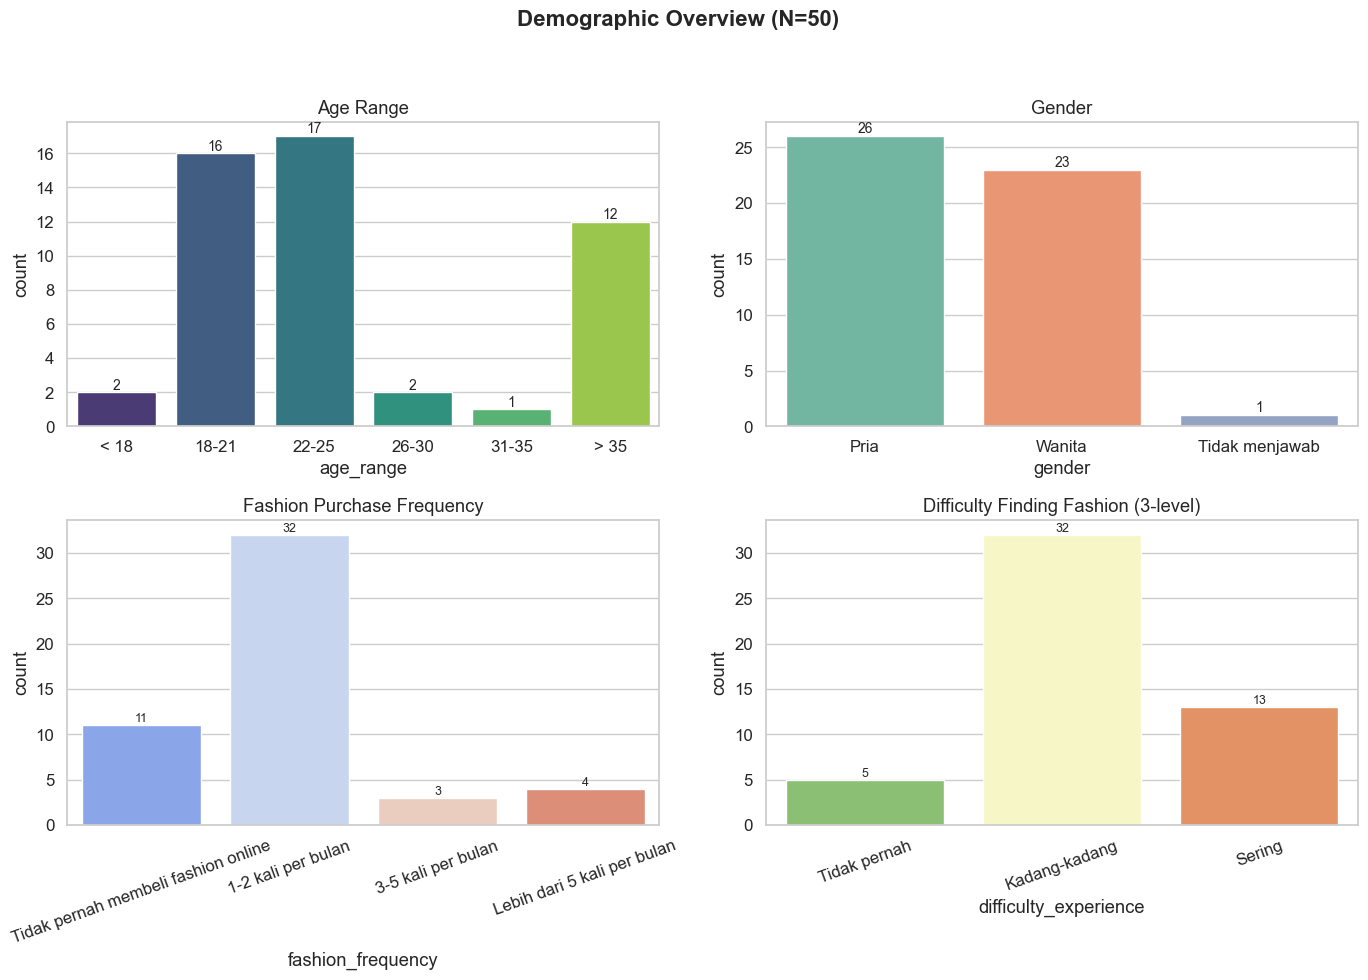

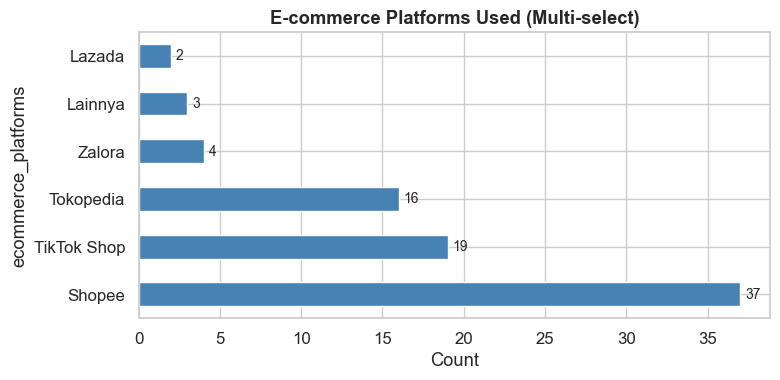


=== Summary Table ===

age_range:
           Count  Pct(%)
age_range               
22-25         17    34.0
18-21         16    32.0
> 35          12    24.0
< 18           2     4.0
26-30          2     4.0
31-35          1     2.0

gender:
                Count  Pct(%)
gender                       
Pria               26    52.0
Wanita             23    46.0
Tidak menjawab      1     2.0

fashion_frequency:
                                     Count  Pct(%)
fashion_frequency                                 
1-2 kali per bulan                      32    64.0
Tidak pernah membeli fashion online     11    22.0
Lebih dari 5 kali per bulan              4     8.0
3-5 kali per bulan                       3     6.0

difficulty_experience:
                       Count  Pct(%)
difficulty_experience               
Kadang-kadang             32    64.0
Sering                    13    26.0
Tidak pernah               5    10.0


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Demographic Overview (N=50)', fontsize=16, fontweight='bold')

# Age range
age_order = ['< 18', '18-21', '22-25', '26-30', '31-35', '> 35']
sns.countplot(data=df, x='age_range', order=age_order, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Age Range')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=10)

# Gender
sns.countplot(data=df, x='gender', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Gender')
for p in axes[0,1].patches:
    axes[0,1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=10)

# Fashion frequency
freq_order = ['Tidak pernah membeli fashion online', '1-2 kali per bulan',
              '3-5 kali per bulan', 'Lebih dari 5 kali per bulan']
sns.countplot(data=df, x='fashion_frequency', order=freq_order, ax=axes[1,0], palette='coolwarm')
axes[1,0].set_title('Fashion Purchase Frequency')
axes[1,0].tick_params(axis='x', rotation=20)
for p in axes[1,0].patches:
    axes[1,0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=9)

# Difficulty experience
diff_order = ['Tidak pernah', 'Kadang-kadang', 'Sering']
sns.countplot(data=df, x='difficulty_experience', order=diff_order, ax=axes[1,1], palette='RdYlGn_r')
axes[1,1].set_title('Difficulty Finding Fashion (3-level)')
axes[1,1].tick_params(axis='x', rotation=20)
for p in axes[1,1].patches:
    axes[1,1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ── Ecommerce platforms (exploded) ──
platforms = (df['ecommerce_platforms']
             .fillna('')
             .str.split(',')
             .explode()
             .str.strip()
             .replace('', np.nan)
             .dropna())

fig, ax = plt.subplots(figsize=(8, 4))
platforms.value_counts().plot.barh(ax=ax, color='steelblue')
ax.set_title('E-commerce Platforms Used (Multi-select)', fontweight='bold')
ax.set_xlabel('Count')
for i, (v, c) in enumerate(platforms.value_counts().items()):
    ax.text(c + 0.3, i, str(c), va='center', fontsize=10)
plt.tight_layout()
plt.show()

# ── Summary table ──
print('\n=== Summary Table ===')
for col in ['age_range', 'gender', 'fashion_frequency', 'difficulty_experience']:
    counts = df[col].value_counts()
    pcts = (counts / len(df) * 100).round(1)
    tbl = pd.DataFrame({'Count': counts, 'Pct(%)': pcts})
    print(f'\n{col}:')
    print(tbl.to_string())

---
## Cell 3 — Cold Start Engagement Analysis

Mean cold-start likes: 2.00
Median: 2.0
Kruskal-Wallis (cold start by gender): H=3.854, p=0.1456
Mann-Whitney U (cold start vs clarity): U=178.0, p=0.1462


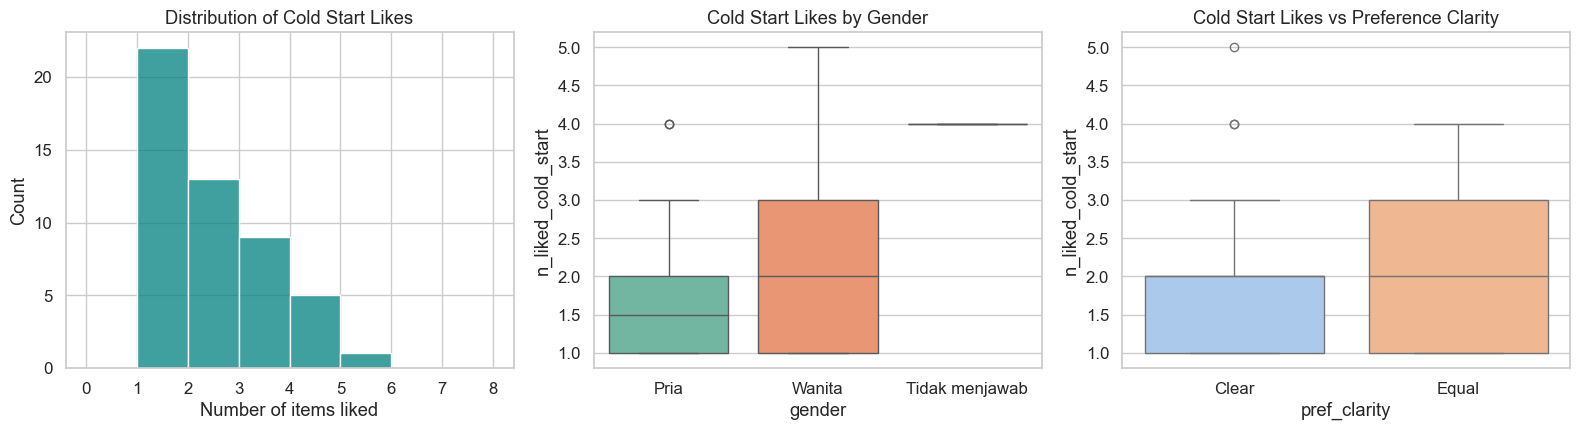

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 3a – Distribution of n_liked_cold_start
sns.histplot(df['n_liked_cold_start'], bins=range(0, 9), kde=False, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Cold Start Likes')
axes[0].set_xlabel('Number of items liked')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
print(f"Mean cold-start likes: {df['n_liked_cold_start'].mean():.2f}")
print(f"Median: {df['n_liked_cold_start'].median():.1f}")

# 3b – Cold start likes by gender
sns.boxplot(data=df, x='gender', y='n_liked_cold_start', ax=axes[1], palette='Set2')
axes[1].set_title('Cold Start Likes by Gender')

# Kruskal-Wallis test across gender groups
groups = [g['n_liked_cold_start'].values for _, g in df.groupby('gender')]
if len(groups) >= 2:
    stat_kw, p_kw = stats.kruskal(*groups)
    print(f'Kruskal-Wallis (cold start by gender): H={stat_kw:.3f}, p={p_kw:.4f}')

# 3c – Cold start likes vs preference clarity
df['pref_clarity'] = df['preferred_engine'].apply(lambda x: 'Clear' if x != 'Equal' else 'Equal')
sns.boxplot(data=df, x='pref_clarity', y='n_liked_cold_start', ax=axes[2], palette='pastel')
axes[2].set_title('Cold Start Likes vs Preference Clarity')

clear_vals = df[df['pref_clarity']=='Clear']['n_liked_cold_start']
equal_vals = df[df['pref_clarity']=='Equal']['n_liked_cold_start']
if len(clear_vals) > 0 and len(equal_vals) > 0:
    stat_u, p_u = stats.mannwhitneyu(clear_vals, equal_vals, alternative='two-sided')
    print(f'Mann-Whitney U (cold start vs clarity): U={stat_u:.1f}, p={p_u:.4f}')

plt.tight_layout()
plt.show()

---
## Cell 4 — Overall A/B Engine Preference

Binomial test (CNN vs Text, n=37): CNN=25, Text=12, p=0.0470
  => Significant at alpha=0.05


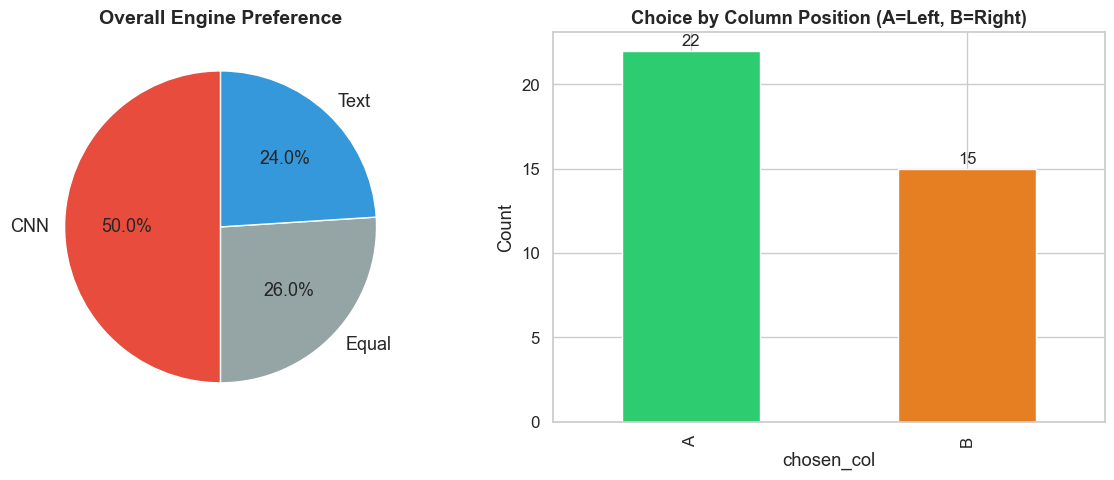


Preference counts: {'CNN': np.int64(25), 'Equal': np.int64(13), 'Text': np.int64(12)}
Equal responses: 13 / 50


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 4a – Pie chart
pref_counts = df['preferred_engine'].value_counts()
colors = {'CNN': '#e74c3c', 'Text': '#3498db', 'Equal': '#95a5a6'}
pie_colors = [colors.get(x, '#ccc') for x in pref_counts.index]
axes[0].pie(pref_counts.values, labels=pref_counts.index, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Overall Engine Preference', fontweight='bold', fontsize=14)

# Binomial test (excluding Equal)
cnn_wins = pref_counts.get('CNN', 0)
text_wins = pref_counts.get('Text', 0)
n_decisive = cnn_wins + text_wins
if n_decisive > 0:
    binom = stats.binomtest(cnn_wins, n_decisive, 0.5, alternative='two-sided').pvalue
    print(f'Binomial test (CNN vs Text, n={n_decisive}): CNN={cnn_wins}, Text={text_wins}, p={binom:.4f}')
    print(f'  => {"Significant" if binom < 0.05 else "Not significant"} at alpha=0.05')

# 4b – Preference by position (A vs B)
pos_data = df.copy()
pos_data['chosen_col'] = pos_data['preference'].apply(lambda x: x if x in ('A','B') else np.nan)
pos_data = pos_data.dropna(subset=['chosen_col'])
pos_counts = pos_data['chosen_col'].value_counts()
pos_counts.plot.bar(ax=axes[1], color=['#2ecc71', '#e67e22'])
axes[1].set_title('Choice by Column Position (A=Left, B=Right)', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (v, c) in enumerate(pos_counts.items()):
    axes[1].text(i, c + 0.3, str(int(c)), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print(f'\nPreference counts: {dict(pref_counts)}')
print(f'Equal responses: {pref_counts.get("Equal", 0)} / {len(df)}')

---
## Cell 5 — Preference by Demographic Segment

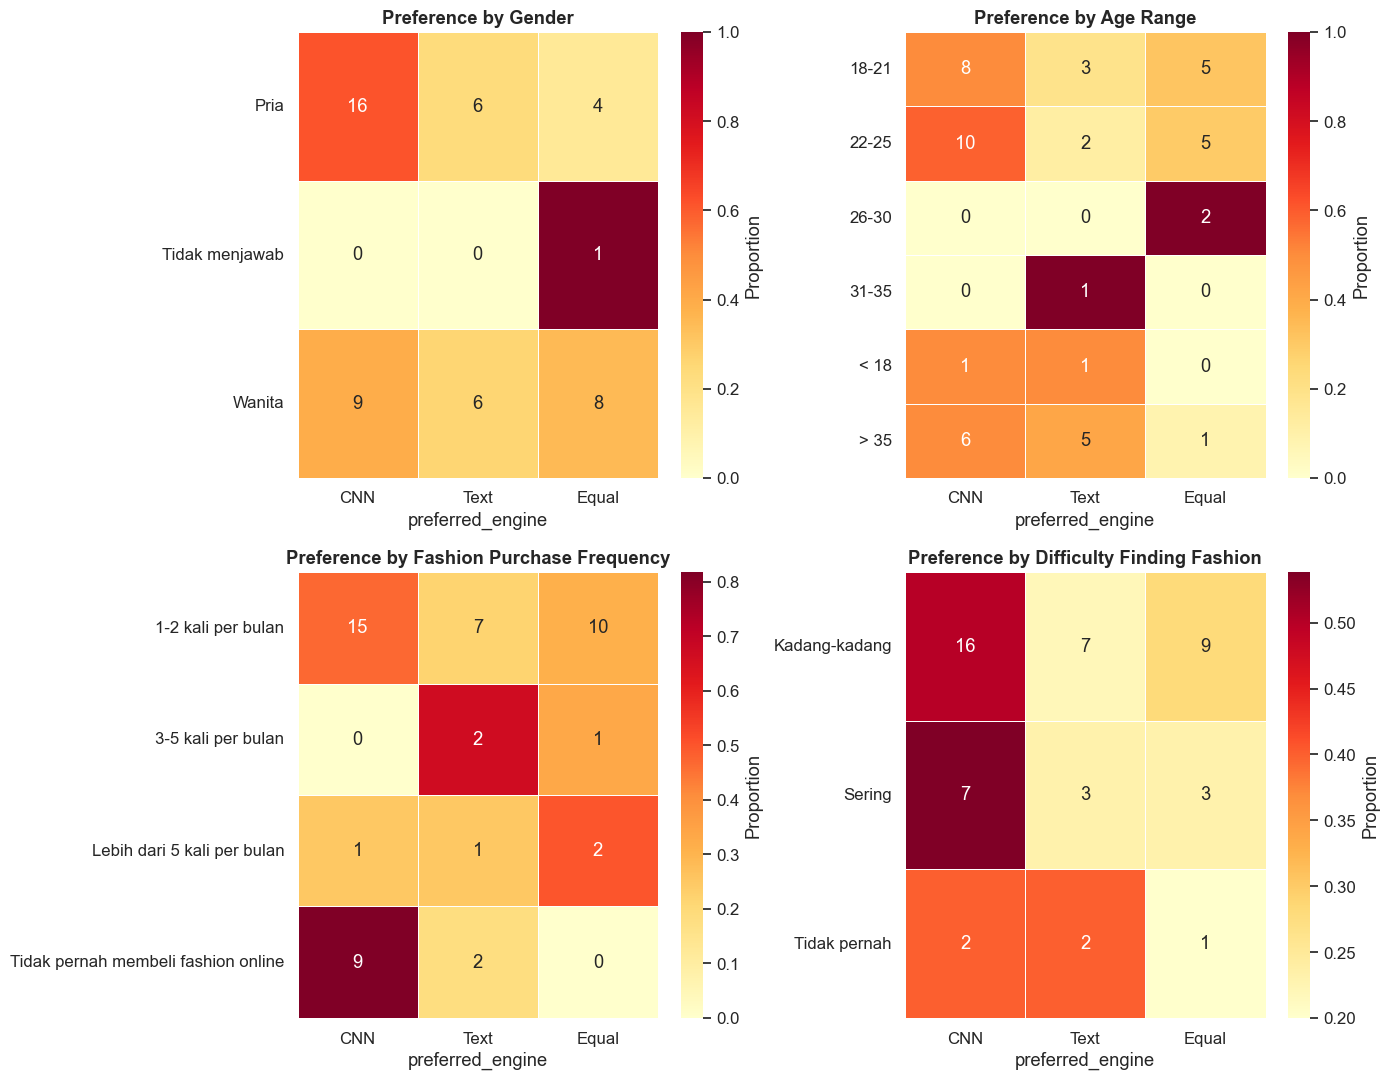


=== Statistical Tests (Preference x Segment) ===
gender: chi2=5.942, dof=4, p=0.2035 (expected counts < 5 in >20% cells — interpret with caution)
age_range: chi2=14.698, dof=10, p=0.1435 (expected counts < 5 in >20% cells — interpret with caution)
fashion_frequency: chi2=10.930, dof=6, p=0.0906 (expected counts < 5 in >20% cells — interpret with caution)
difficulty_experience: chi2=0.904, dof=4, p=0.9240 (expected counts < 5 in >20% cells — interpret with caution)


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
segments = ['gender', 'age_range', 'fashion_frequency', 'difficulty_experience']
titles = ['Gender', 'Age Range', 'Fashion Purchase Frequency', 'Difficulty Finding Fashion']
pref_order = ['CNN', 'Text', 'Equal']

for idx, (seg, title) in enumerate(zip(segments, titles)):
    ax = axes[idx // 2][idx % 2]
    ct = pd.crosstab(df[seg], df['preferred_engine'])
    ct = ct.reindex(columns=pref_order, fill_value=0)
    # Normalize row-wise for heatmap
    ct_norm = ct.div(ct.sum(axis=1), axis=0)
    sns.heatmap(ct_norm, annot=ct, fmt='d', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Proportion'}, linewidths=0.5)
    ax.set_title(f'Preference by {title}', fontweight='bold')
    ax.set_ylabel('')
    ax.tick_params(axis='y', rotation=0)
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ── Statistical tests ──
print('\n=== Statistical Tests (Preference x Segment) ===')
for seg in segments:
    ct = pd.crosstab(df[seg], df['preferred_engine'])
    ct = ct.reindex(columns=pref_order, fill_value=0)
    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
        chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
        # Use Fisher for small expected counts
        if (expected < 5).sum() > 0.2 * expected.size:
            note = ' (expected counts < 5 in >20% cells — interpret with caution)'
        else:
            note = ''
        print(f'{seg}: chi2={chi2:.3f}, dof={dof}, p={p_chi:.4f}{note}')
    else:
        print(f'{seg}: insufficient groups for test')

---
## Cell 6 — Recommendation Engagement (Precision@8 Proxy)

=== Hit Rate (@8) Summary ===
CNN  — mean: 0.242, median: 0.250, std: 0.228
Text — mean: 0.172, median: 0.125, std: 0.190

Wilcoxon signed-rank test: W=95.0, p=0.0070
  => Significant at alpha=0.05
Paired t-test: t=2.217, p=0.0313


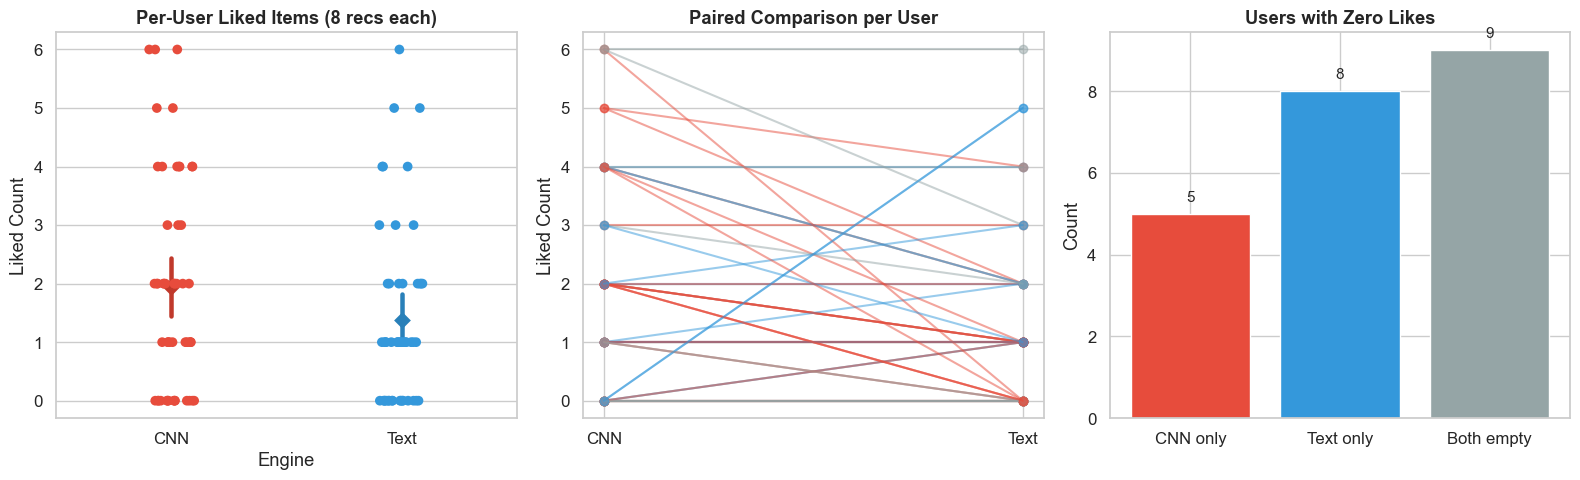

In [7]:
# Per-user hit rate
df['hit_cnn']  = df['n_liked_cnn']  / 8.0
df['hit_text'] = df['n_liked_text'] / 8.0

print('=== Hit Rate (@8) Summary ===')
print(f"CNN  — mean: {df['hit_cnn'].mean():.3f}, median: {df['hit_cnn'].median():.3f}, std: {df['hit_cnn'].std():.3f}")
print(f"Text — mean: {df['hit_text'].mean():.3f}, median: {df['hit_text'].median():.3f}, std: {df['hit_text'].std():.3f}")

# Wilcoxon signed-rank test (paired, non-parametric)
stat_w, p_w = stats.wilcoxon(df['hit_cnn'], df['hit_text'], alternative='two-sided')
print(f'\nWilcoxon signed-rank test: W={stat_w:.1f}, p={p_w:.4f}')
print(f'  => {"Significant" if p_w < 0.05 else "Not significant"} at alpha=0.05')

# Paired t-test as reference
stat_t, p_t = stats.ttest_rel(df['hit_cnn'], df['hit_text'])
print(f'Paired t-test: t={stat_t:.3f}, p={p_t:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a – Paired strip plot
melted = df.melt(value_vars=['n_liked_cnn', 'n_liked_text'],
                 var_name='Engine', value_name='Liked Count')
melted['Engine'] = melted['Engine'].map({'n_liked_cnn': 'CNN', 'n_liked_text': 'Text'})
sns.stripplot(data=melted, x='Engine', y='Liked Count', jitter=True,
              palette={'CNN': '#e74c3c', 'Text': '#3498db'}, ax=axes[0], size=7)
sns.pointplot(data=melted, x='Engine', y='Liked Count',
              palette={'CNN': '#c0392b', 'Text': '#2980b9'}, ax=axes[0],
              join=False, ci=95, markers='D', scale=1.2)
axes[0].set_title('Per-User Liked Items (8 recs each)', fontweight='bold')

# 6b – Paired line plot (per user)
for i, row in df.iterrows():
    color = '#e74c3c' if row['preferred_engine'] == 'CNN' else (
        '#3498db' if row['preferred_engine'] == 'Text' else '#95a5a6')
    axes[1].plot([0, 1], [row['n_liked_cnn'], row['n_liked_text']],
                 marker='o', color=color, alpha=0.5, linewidth=1.5)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['CNN', 'Text'])
axes[1].set_ylabel('Liked Count')
axes[1].set_title('Paired Comparison per User', fontweight='bold')

# 6c – Empty responses
empty_both = ((df['n_liked_cnn'] == 0) & (df['n_liked_text'] == 0)).sum()
empty_cnn  = (df['n_liked_cnn'] == 0).sum()
empty_text = (df['n_liked_text'] == 0).sum()
bars = axes[2].bar(['CNN only', 'Text only', 'Both empty'],
                   [empty_cnn - empty_both, empty_text - empty_both, empty_both],
                   color=['#e74c3c', '#3498db', '#95a5a6'])
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', fontsize=11)
axes[2].set_title('Users with Zero Likes', fontweight='bold')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

---
## Cell 7 — Category-Level Analysis (Join with Master Dataset)

Total liked item records: 166
Unique items liked: 158


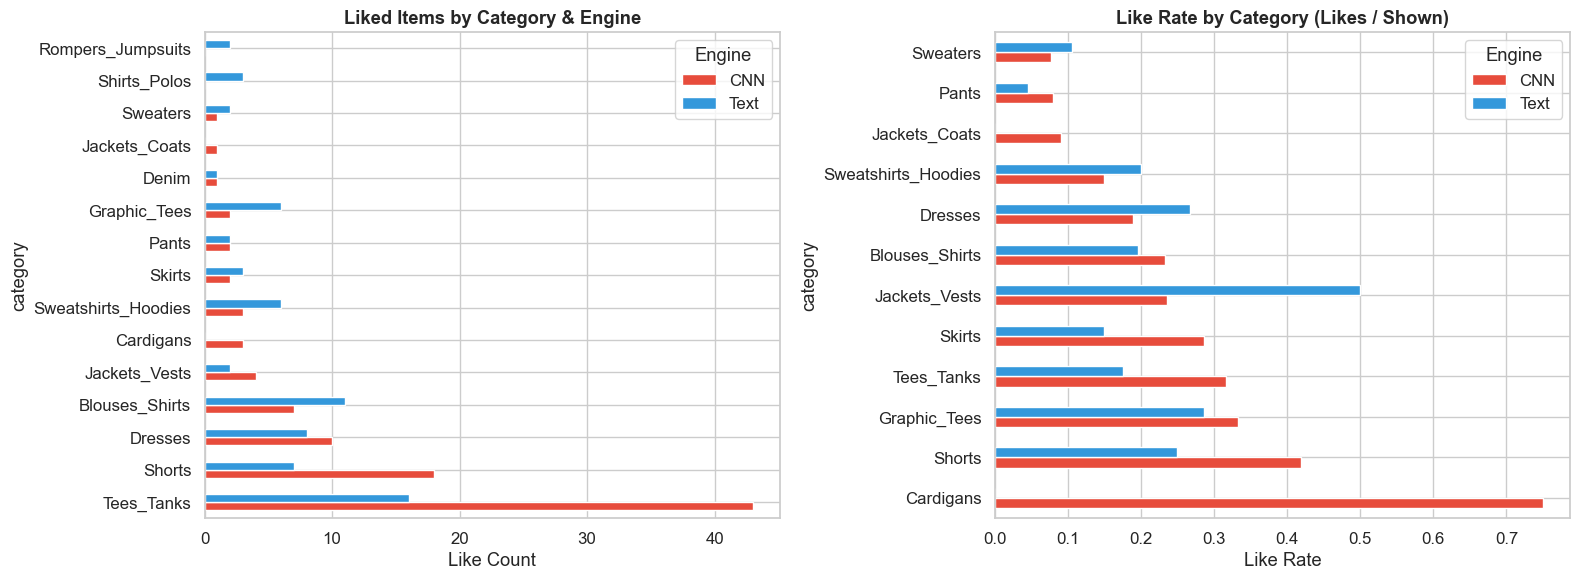


=== Gender Match Rate ===
CNN: 84.9% of liked items match user gender
Text: 80.0% of liked items match user gender


In [8]:
# Build long-form: each liked item -> its category/gender from master
rows = []
for _, r in df.iterrows():
    for idx in r['liked_a_items_list']:
        engine = 'CNN' if r['engine_a_is_cnn'] else 'Text'
        rows.append({'session_id': r['session_id'], 'item_idx': idx, 'engine': engine,
                     'user_gender': r['gender']})
    for idx in r['liked_b_items_list']:
        engine = 'Text' if r['engine_a_is_cnn'] else 'CNN'
        rows.append({'session_id': r['session_id'], 'item_idx': idx, 'engine': engine,
                     'user_gender': r['gender']})

liked_long = pd.DataFrame(rows)
liked_long = liked_long.merge(item_meta, on='item_idx', how='left')

print(f'Total liked item records: {len(liked_long)}')
print(f'Unique items liked: {liked_long["item_idx"].nunique()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7a – Category distribution per engine
cat_ct = pd.crosstab(liked_long['category'], liked_long['engine'])
cat_ct = cat_ct.sort_values('CNN', ascending=False)
cat_ct.plot.barh(ax=axes[0], color={'CNN': '#e74c3c', 'Text': '#3498db'})
axes[0].set_title('Liked Items by Category & Engine', fontweight='bold')
axes[0].set_xlabel('Like Count')
axes[0].legend(title='Engine')

# 7b – Per-category like rate (normalized by recs shown per category)
# Count how many times each category was shown per engine
rec_rows = []
for _, r in df.iterrows():
    for idx in r['recs_a_items_list']:
        engine = 'CNN' if r['engine_a_is_cnn'] else 'Text'
        rec_rows.append({'item_idx': idx, 'engine': engine})
    for idx in r['recs_b_items_list']:
        engine = 'Text' if r['engine_a_is_cnn'] else 'CNN'
        rec_rows.append({'item_idx': idx, 'engine': engine})

recs_long = pd.DataFrame(rec_rows).merge(item_meta, on='item_idx', how='left')

shown_ct = pd.crosstab(recs_long['category'], recs_long['engine'])
like_ct  = pd.crosstab(liked_long['category'], liked_long['engine'])
# Align
all_cats = shown_ct.index.union(like_ct.index)
shown_ct = shown_ct.reindex(all_cats, fill_value=0)
like_ct  = like_ct.reindex(all_cats, fill_value=0)

rate_ct = like_ct / shown_ct.replace(0, np.nan)
rate_ct = rate_ct.dropna(how='all').sort_values('CNN', ascending=False).head(12)
rate_ct.plot.barh(ax=axes[1], color={'CNN': '#e74c3c', 'Text': '#3498db'})
axes[1].set_title('Like Rate by Category (Likes / Shown)', fontweight='bold')
axes[1].set_xlabel('Like Rate')
axes[1].legend(title='Engine')

plt.tight_layout()
plt.show()

# 7c – Gender match analysis
gender_map = {'Pria': 'MEN', 'Wanita': 'WOMEN'}
liked_long['user_gender_mapped'] = liked_long['user_gender'].map(gender_map)
liked_long['gender_match'] = liked_long['user_gender_mapped'] == liked_long['gender']

matchable = liked_long.dropna(subset=['user_gender_mapped'])
print('\n=== Gender Match Rate ===')
for eng in ['CNN', 'Text']:
    sub = matchable[matchable['engine'] == eng]
    match_pct = sub['gender_match'].mean() * 100 if len(sub) > 0 else 0
    print(f'{eng}: {match_pct:.1f}% of liked items match user gender')

---
## Cell 8 — Cold Start to Recommendation Quality Link

=== Cold Start Item Gender vs Engine Preference ===
preferred_engine  CNN  Equal  Text
gender                            
MEN                29     13     7
WOMEN              18     18    15

--- Users who liked >= 1 MEN cold-start item ---
Count: 32
preferred_engine
CNN      18
Equal     8
Text      6
Name: count, dtype: int64

--- Users who liked 0 MEN cold-start items ---
Count: 18
preferred_engine
CNN      7
Text     6
Equal    5
Name: count, dtype: int64

--- Users who liked >= 1 WOMEN cold-start item ---
Count: 27
preferred_engine
CNN      10
Equal     9
Text      8
Name: count, dtype: int64

--- Users who liked 0 WOMEN cold-start items ---
Count: 23
preferred_engine
CNN      15
Equal     4
Text      4
Name: count, dtype: int64

Spearman correlation (cold_start_likes vs total_rec_likes): rho=0.407, p=0.0034


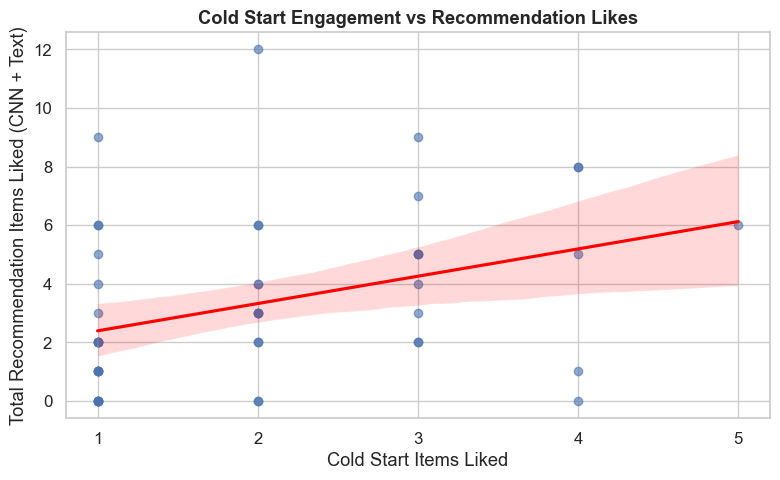

In [9]:
# Analyze cold start item genders and relation to preference
cs_rows = []
for _, r in df.iterrows():
    for idx in r['liked_cold_start_list']:
        cs_rows.append({'session_id': r['session_id'], 'item_idx': idx,
                        'preferred_engine': r['preferred_engine'], 'user_gender': r['gender']})

cs_long = pd.DataFrame(cs_rows).merge(item_meta, on='item_idx', how='left')

# 8a – Gender of cold-start liked items vs preference
print('=== Cold Start Item Gender vs Engine Preference ===')
cs_pref = pd.crosstab(cs_long['gender'], cs_long['preferred_engine'])
print(cs_pref)
print()

# Per-user aggregation of cold start gender engagement
user_cs_gender = cs_long.groupby('session_id').agg(
    n_men_cs=('gender', lambda x: (x == 'MEN').sum()),
    n_women_cs=('gender', lambda x: (x == 'WOMEN').sum()),
    preferred_engine=('preferred_engine', 'first')
).reset_index()

# ── 8b – Men's cold start items & preference ──
print('--- Users who liked >= 1 MEN cold-start item ---')
men_cs_users = user_cs_gender[user_cs_gender['n_men_cs'] >= 1]
print(f'Count: {len(men_cs_users)}')
print(men_cs_users['preferred_engine'].value_counts())
print()
print('--- Users who liked 0 MEN cold-start items ---')
no_men_cs = user_cs_gender[user_cs_gender['n_men_cs'] == 0]
print(f'Count: {len(no_men_cs)}')
print(no_men_cs['preferred_engine'].value_counts())
print()

# ── 8c – Women's cold start items & preference ──
print('--- Users who liked >= 1 WOMEN cold-start item ---')
women_cs_users = user_cs_gender[user_cs_gender['n_women_cs'] >= 1]
print(f'Count: {len(women_cs_users)}')
print(women_cs_users['preferred_engine'].value_counts())
print()
print('--- Users who liked 0 WOMEN cold-start items ---')
no_women_cs = user_cs_gender[user_cs_gender['n_women_cs'] == 0]
print(f'Count: {len(no_women_cs)}')
print(no_women_cs['preferred_engine'].value_counts())
print()

# ── 8d – Correlation: n_liked_cold_start vs total recommendation likes ──
df['total_rec_likes'] = df['n_liked_cnn'] + df['n_liked_text']
rho, p_spearman = stats.spearmanr(df['n_liked_cold_start'], df['total_rec_likes'])
print(f'Spearman correlation (cold_start_likes vs total_rec_likes): rho={rho:.3f}, p={p_spearman:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x='n_liked_cold_start', y='total_rec_likes',
            scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=ax)
ax.set_title('Cold Start Engagement vs Recommendation Likes', fontweight='bold')
ax.set_xlabel('Cold Start Items Liked')
ax.set_ylabel('Total Recommendation Items Liked (CNN + Text)')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

---
## Cell 9 — Position Bias Check

=== Position Bias Crosstab ===
preferred_engine  CNN  Text
cnn_position               
Left (A)           14     4
Right (B)          11     8

Chi-squared test (position x preference): chi2=0.884, p=0.3472
  => No significant position bias at alpha=0.05


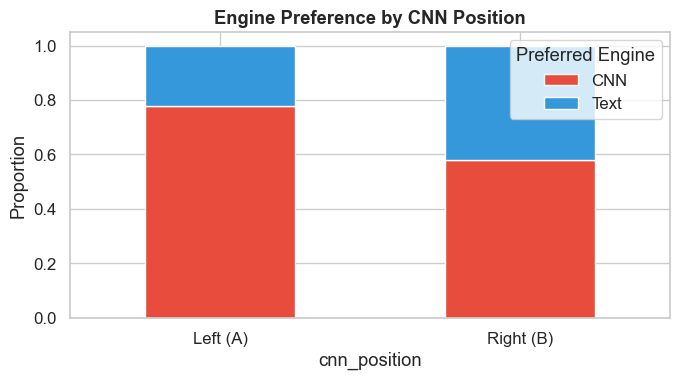


Raw column choice: A=22, B=15, Equal=13
Binomial test A vs B: p=0.3240


In [10]:
# Check if column position (A=left, B=right) biases preference
pos_df = df.copy()
# Where is CNN shown?
pos_df['cnn_position'] = pos_df['engine_a_is_cnn'].apply(lambda x: 'Left (A)' if x else 'Right (B)')
# Exclude 'equal' for bias test
decisive = pos_df[pos_df['preferred_engine'] != 'Equal']

ct_pos = pd.crosstab(decisive['cnn_position'], decisive['preferred_engine'])
print('=== Position Bias Crosstab ===')
print(ct_pos)
print()

if ct_pos.shape == (2, 2):
    chi2, p_chi, _, _ = stats.chi2_contingency(ct_pos, correction=True)
    print(f'Chi-squared test (position x preference): chi2={chi2:.3f}, p={p_chi:.4f}')
    print(f'  => {"Significant position bias" if p_chi < 0.05 else "No significant position bias"} at alpha=0.05')
else:
    print('Insufficient data for 2x2 chi-squared test.')

fig, ax = plt.subplots(figsize=(7, 4))
ct_pos_norm = ct_pos.div(ct_pos.sum(axis=1), axis=0)
ct_pos_norm.plot.bar(stacked=True, ax=ax, color={'CNN': '#e74c3c', 'Text': '#3498db'})
ax.set_title('Engine Preference by CNN Position', fontweight='bold')
ax.set_ylabel('Proportion')
ax.legend(title='Preferred Engine')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Also test: raw A/B choice frequency
ab_counts = df['preference'].value_counts()
print(f'\nRaw column choice: A={ab_counts.get("A",0)}, B={ab_counts.get("B",0)}, Equal={ab_counts.get("equal",0)}')
if ab_counts.get('A', 0) + ab_counts.get('B', 0) > 0:
    binom_ab = stats.binomtest(ab_counts.get('A',0),
                                ab_counts.get('A',0) + ab_counts.get('B',0), 0.5).pvalue
    print(f'Binomial test A vs B: p={binom_ab:.4f}')

---
## Cell 10 — Summary & Key Insights

In [11]:
# ── Consolidated Summary Table ──
print('=' * 60)
print('       USER STUDY ANALYSIS — CONSOLIDATED SUMMARY')
print('=' * 60)

print(f'\n1. RESPONDENTS: {len(df)} users')
print(f'   - Gender: {df["gender"].value_counts().to_dict()}')
print(f'   - Age: {df["age_range"].value_counts().to_dict()}')

print(f'\n2. ENGINE PREFERENCE:')
for eng, cnt in pref_counts.items():
    print(f'   - {eng}: {cnt} ({cnt/len(df)*100:.1f}%)')
if n_decisive > 0:
    print(f'   Binomial test (excl. Equal): p={binom:.4f}')

print(f'\n3. HIT RATE (@8):')
print(f'   - CNN  mean: {df["hit_cnn"].mean():.3f}  ({df["hit_cnn"].mean()*100:.1f}%)')
print(f'   - Text mean: {df["hit_text"].mean():.3f}  ({df["hit_text"].mean()*100:.1f}%)')
print(f'   Wilcoxon p={p_w:.4f}, Paired t-test p={p_t:.4f}')

print(f'\n4. COLD START:')
print(f'   Mean items liked: {df["n_liked_cold_start"].mean():.2f}')
print(f'   Spearman (cold start vs rec likes): rho={rho:.3f}, p={p_spearman:.4f}')

print(f'\n5. POSITION BIAS:')
if ct_pos.shape == (2, 2):
    print(f'   Chi-squared p={p_chi:.4f} — {"Bias detected" if p_chi < 0.05 else "No bias"}')

print(f'\n6. ZERO-LIKE USERS:')
print(f'   CNN empty: {empty_cnn}, Text empty: {empty_text}, Both empty: {empty_both}')

# ── Key Insights ──
print('\n' + '=' * 60)
print('       KEY INSIGHTS')
print('=' * 60)

# Determine overall winner
if cnn_wins > text_wins and binom < 0.05:
    winner = 'CNN significantly preferred over Text'
elif text_wins > cnn_wins and binom < 0.05:
    winner = 'Text significantly preferred over CNN'
elif cnn_wins > text_wins:
    winner = f'CNN leads ({cnn_wins} vs {text_wins}) but not statistically significant (p={binom:.3f})'
elif text_wins > cnn_wins:
    winner = f'Text leads ({text_wins} vs {cnn_wins}) but not statistically significant (p={binom:.3f})'
else:
    winner = 'No clear preference between CNN and Text'
print(f'\n  1. OVERALL: {winner}')

# Equal responses
eq_pct = pref_counts.get('Equal', 0) / len(df) * 100
print(f'  2. {pref_counts.get("Equal", 0)} users ({eq_pct:.0f}%) found both engines equally good/bad.')

# Hit rate
if p_w < 0.05:
    hr_note = 'significant difference in hit rate'
else:
    hr_note = 'no significant difference in hit rate'
better = 'CNN' if df['hit_cnn'].mean() > df['hit_text'].mean() else 'Text'
print(f'  3. HIT RATE: {better} has higher average hit rate, but {hr_note} (Wilcoxon p={p_w:.3f}).')

# Cold start
cs_pct = (df['n_liked_cold_start'] >= 2).sum() / len(df) * 100
print(f'  4. COLD START: {cs_pct:.0f}% of users liked >= 2 cold start items, indicating good initial engagement.')

# Position bias
if ct_pos.shape == (2, 2) and p_chi >= 0.05:
    print(f'  5. VALIDITY: No position bias detected (p={p_chi:.3f}), supporting the integrity of preferences.')
elif ct_pos.shape == (2, 2):
    print(f'  5. CAUTION: Position bias detected (p={p_chi:.3f}), preferences may be influenced by layout.')

print('\n' + '=' * 60)

       USER STUDY ANALYSIS — CONSOLIDATED SUMMARY

1. RESPONDENTS: 50 users
   - Gender: {'Pria': 26, 'Wanita': 23, 'Tidak menjawab': 1}
   - Age: {'22-25': 17, '18-21': 16, '> 35': 12, '< 18': 2, '26-30': 2, '31-35': 1}

2. ENGINE PREFERENCE:
   - CNN: 25 (50.0%)
   - Equal: 13 (26.0%)
   - Text: 12 (24.0%)
   Binomial test (excl. Equal): p=0.0470

3. HIT RATE (@8):
   - CNN  mean: 0.242  (24.2%)
   - Text mean: 0.172  (17.2%)
   Wilcoxon p=0.0070, Paired t-test p=0.0313

4. COLD START:
   Mean items liked: 2.00
   Spearman (cold start vs rec likes): rho=0.407, p=0.0034

5. POSITION BIAS:
   Chi-squared p=0.3472 — No bias

6. ZERO-LIKE USERS:
   CNN empty: 14, Text empty: 17, Both empty: 9

       KEY INSIGHTS

  1. OVERALL: CNN significantly preferred over Text
  2. 13 users (26%) found both engines equally good/bad.
  3. HIT RATE: CNN has higher average hit rate, but significant difference in hit rate (Wilcoxon p=0.007).
  4. COLD START: 56% of users liked >= 2 cold start items, ind